In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [26]:
df = pd.read_csv('../data/simulation_results.csv')

df_srtf = df[df['Scheduler'] == 'SRTF'].reset_index(drop=True)
df_modified = df[df['Scheduler'] == 'Modified_SRTF'].reset_index(drop=True)

utilization_levels = df_srtf['Utilization'].values
x = np.arange(len(utilization_levels))
width = 0.35

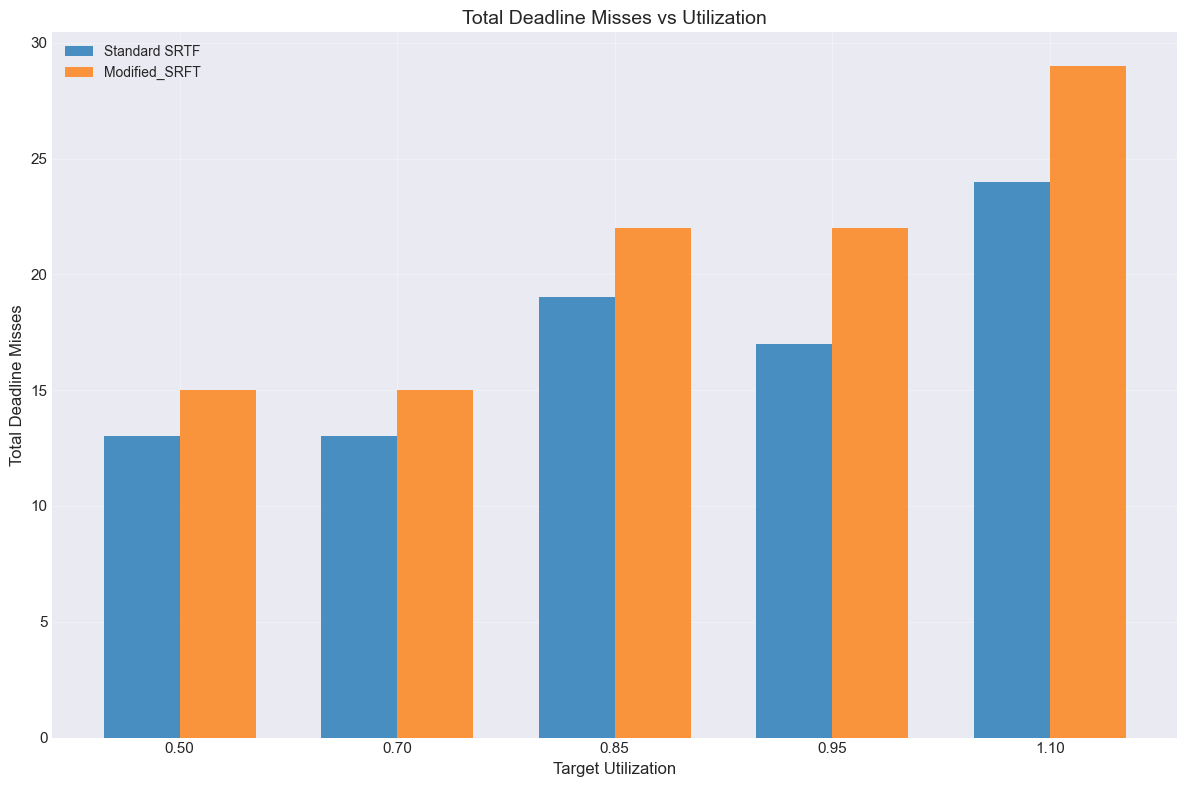

In [27]:
#deadline misses comparison
fig, ax1 = plt.subplots(figsize=(12, 8))

bars1 = ax1.bar(x - width/2, df_srtf['DeadlineMisses'], width, label='Standard SRTF', alpha=0.8)
bars2 = ax1.bar(x + width/2, df_modified['DeadlineMisses'], width, label='Modified_SRFT', alpha=0.8)

ax1.set_xlabel('Target Utilization')
ax1.set_ylabel('Total Deadline Misses')
ax1.set_title('Total Deadline Misses vs Utilization')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{u:.2f}' for u in utilization_levels])
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

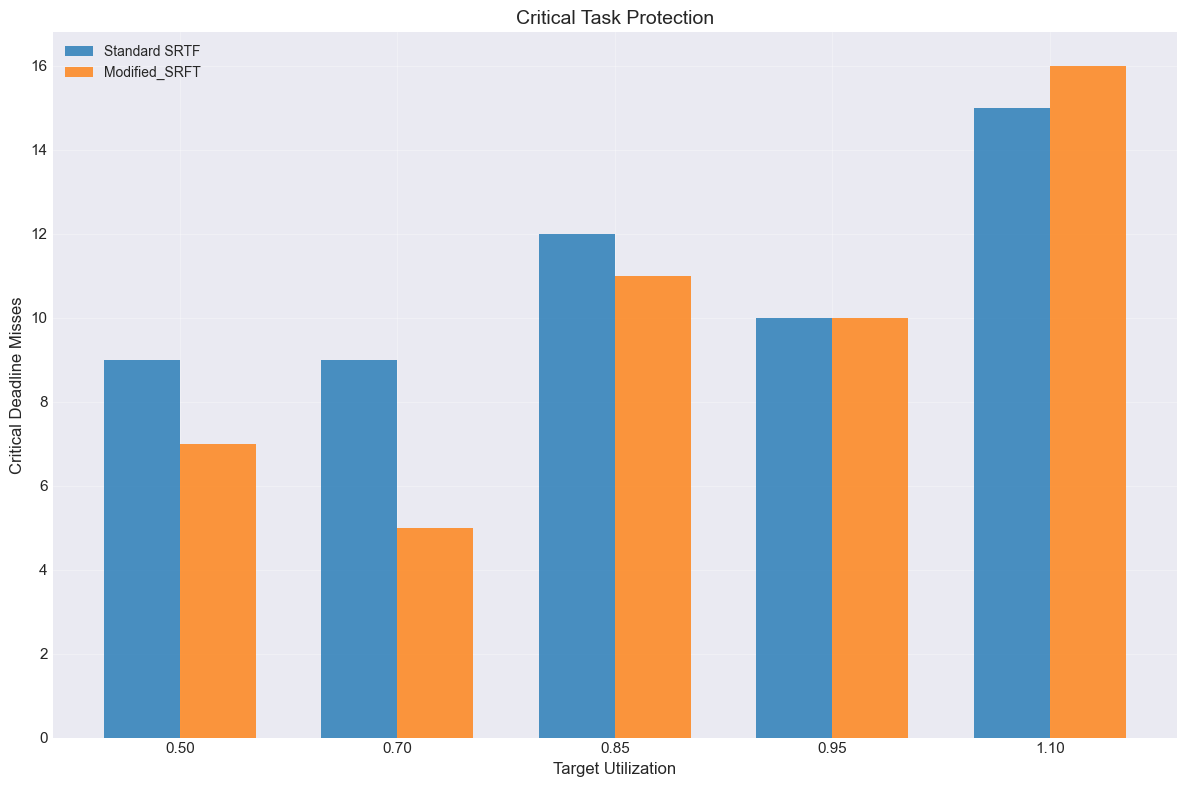

In [29]:
fig, ax2 = plt.subplots(figsize=(12, 8))

bars1 = ax2.bar(x - width/2, df_srtf['CriticalMisses'], width, label='Standard SRTF', alpha=0.8)
bars2 = ax2.bar(x + width/2, df_modified['CriticalMisses'], width, label='Modified_SRFT', alpha=0.8)

ax2.set_xlabel('Target Utilization')
ax2.set_ylabel('Critical Deadline Misses')
ax2.set_title('Critical Task Protection')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{u:.2f}' for u in utilization_levels])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

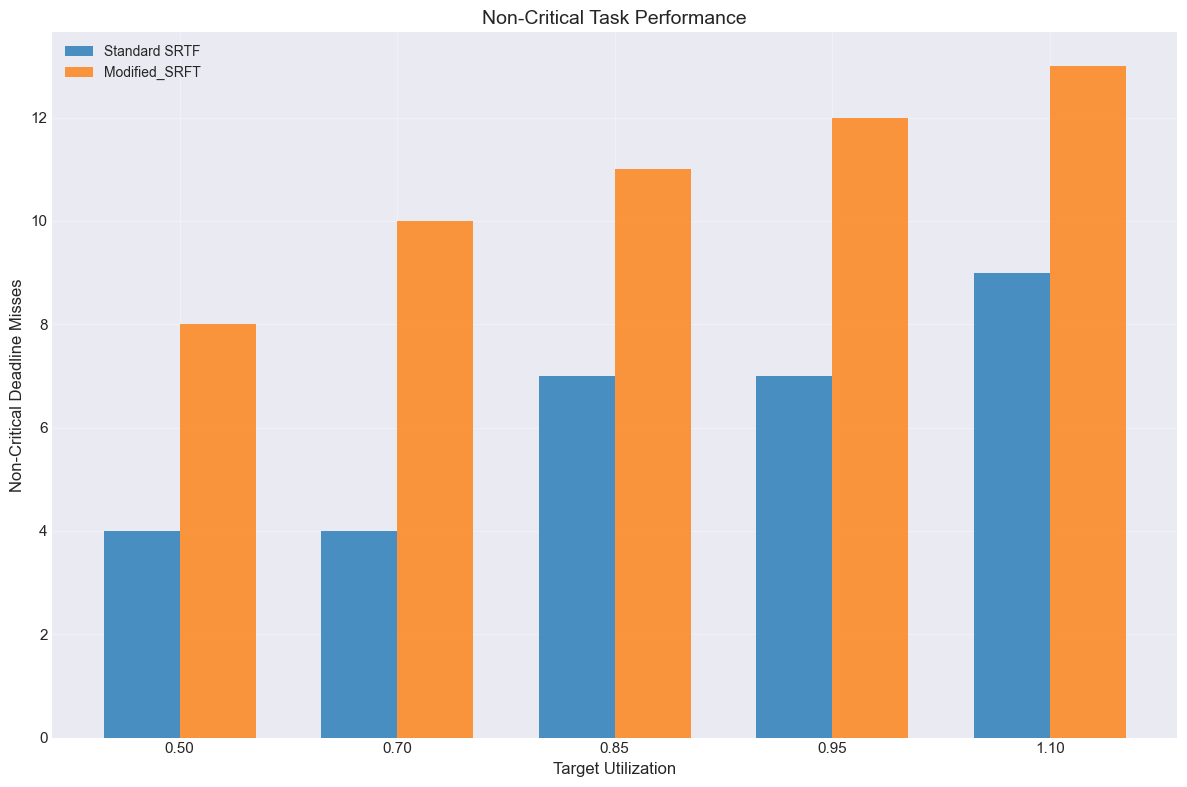

In [30]:
fig, ax3 = plt.subplots(figsize=(12, 8))

bars1 = ax3.bar(x - width/2, df_srtf['NonCriticalMisses'], width, label='Standard SRTF', alpha=0.8)
bars2 = ax3.bar(x + width/2, df_modified['NonCriticalMisses'], width, label='Modified_SRFT', alpha=0.8)

ax3.set_xlabel('Target Utilization')
ax3.set_ylabel('Non-Critical Deadline Misses')
ax3.set_title('Non-Critical Task Performance')
ax3.set_xticks(x)
ax3.set_xticklabels([f'{u:.2f}' for u in utilization_levels])
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

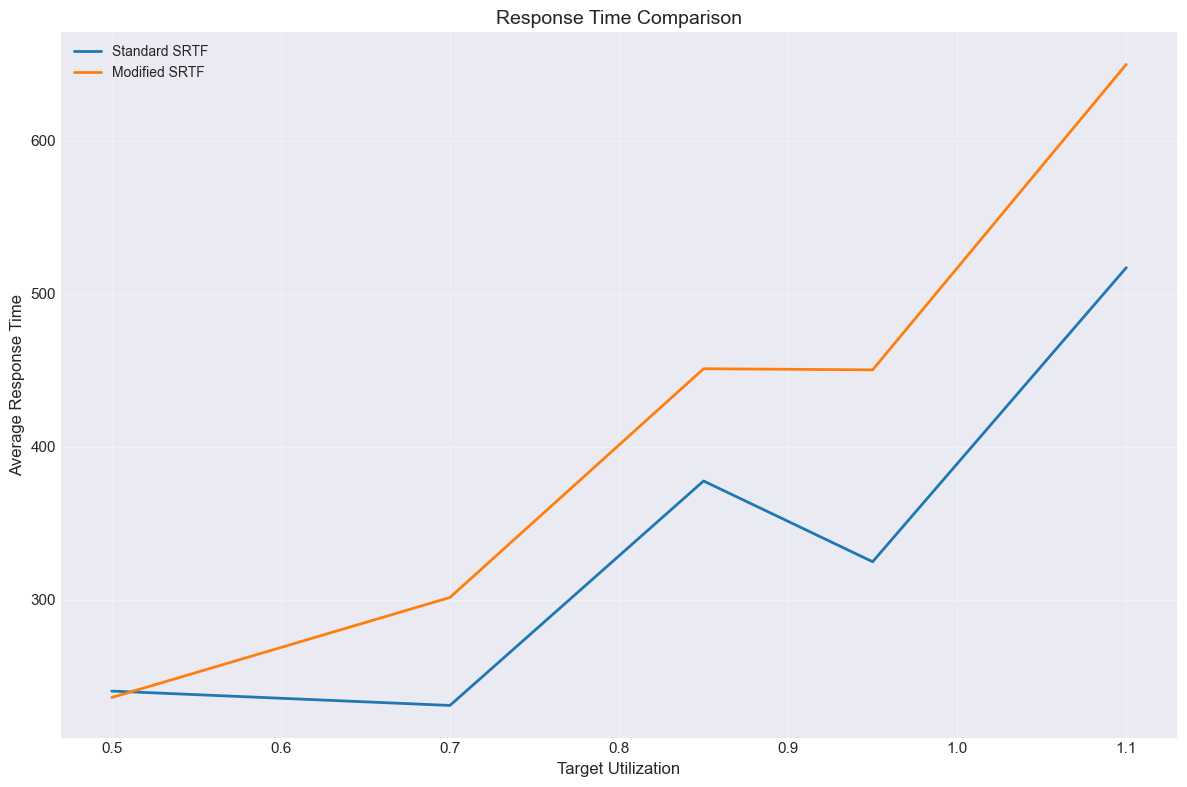

In [31]:
fig, ax4 = plt.subplots(figsize=(12, 8))

ax4.plot(utilization_levels, df_srtf['AvgResponseTime'], label='Standard SRTF', linewidth=2, markersize=8)
ax4.plot(utilization_levels, df_modified['AvgResponseTime'], label='Modified SRTF', linewidth=2, markersize=8)

ax4.set_xlabel('Target Utilization')
ax4.set_ylabel('Average Response Time')
ax4.set_title('Response Time Comparison')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

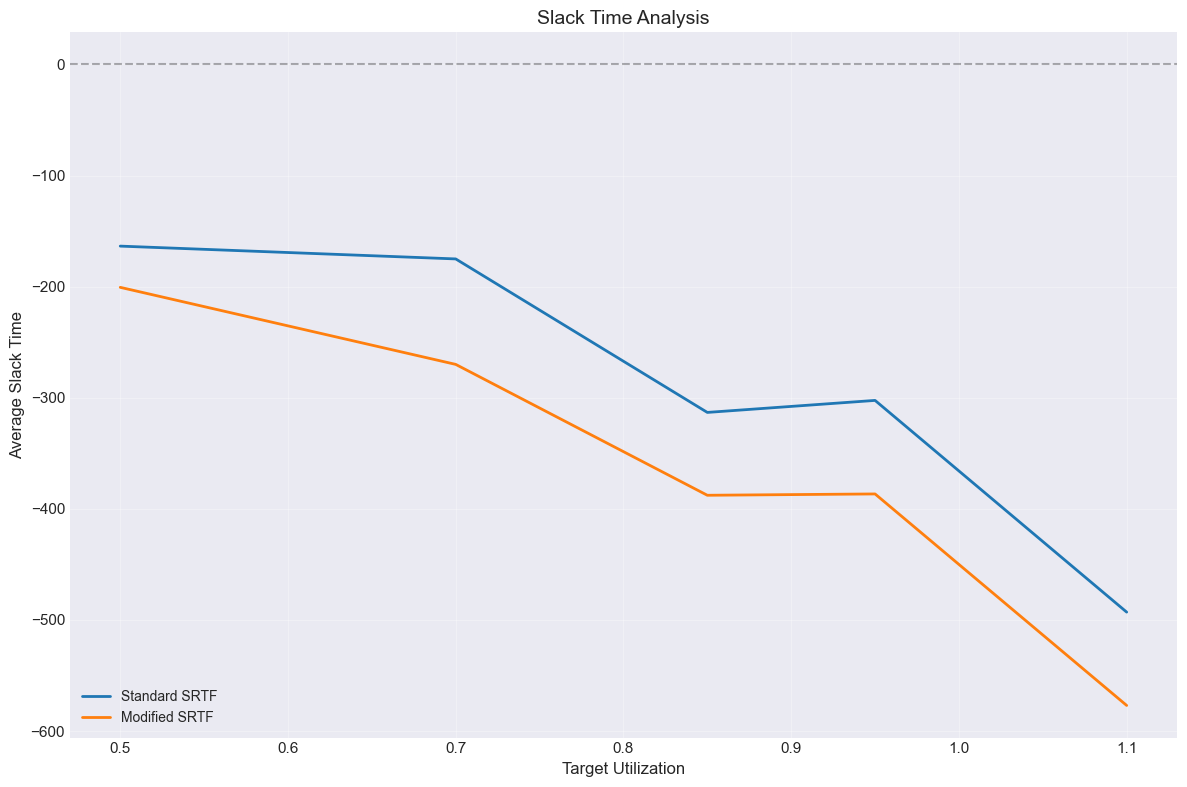

In [32]:
fig, ax5 = plt.subplots(figsize=(12, 8))

ax5.plot(utilization_levels, df_srtf['AvgSlackTime'], label='Standard SRTF', linewidth=2, markersize=8)
ax5.plot(utilization_levels, df_modified['AvgSlackTime'], label='Modified SRTF', linewidth=2, markersize=8)

ax5.set_xlabel('Target Utilization')
ax5.set_ylabel('Average Slack Time')
ax5.set_title('Slack Time Analysis')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

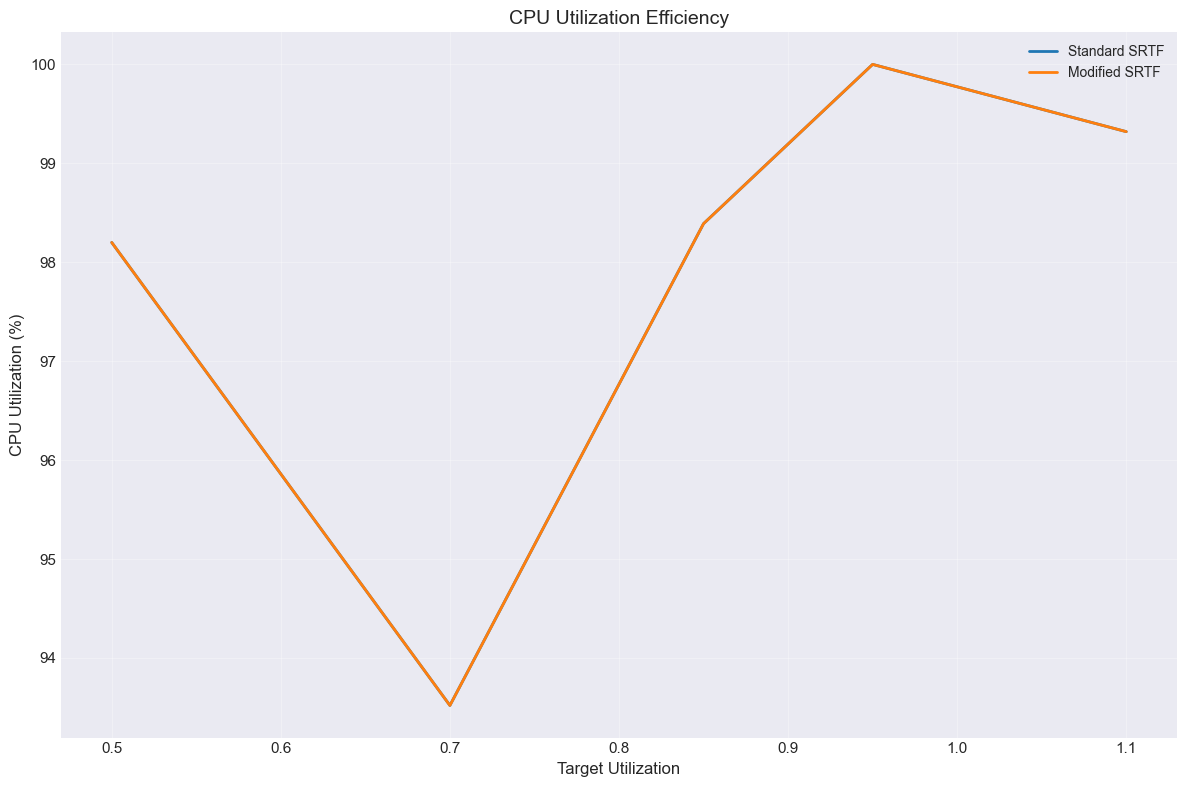

In [34]:
fig, ax6 = plt.subplots(figsize=(12, 8))

ax6.plot(utilization_levels, df_srtf['CPUUtilization'], label='Standard SRTF', linewidth=2, markersize=8)
ax6.plot(utilization_levels, df_modified['CPUUtilization'], label='Modified SRTF', linewidth=2, markersize=8)

ax6.set_xlabel('Target Utilization')
ax6.set_ylabel('CPU Utilization (%)')
ax6.set_title('CPU Utilization Efficiency')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

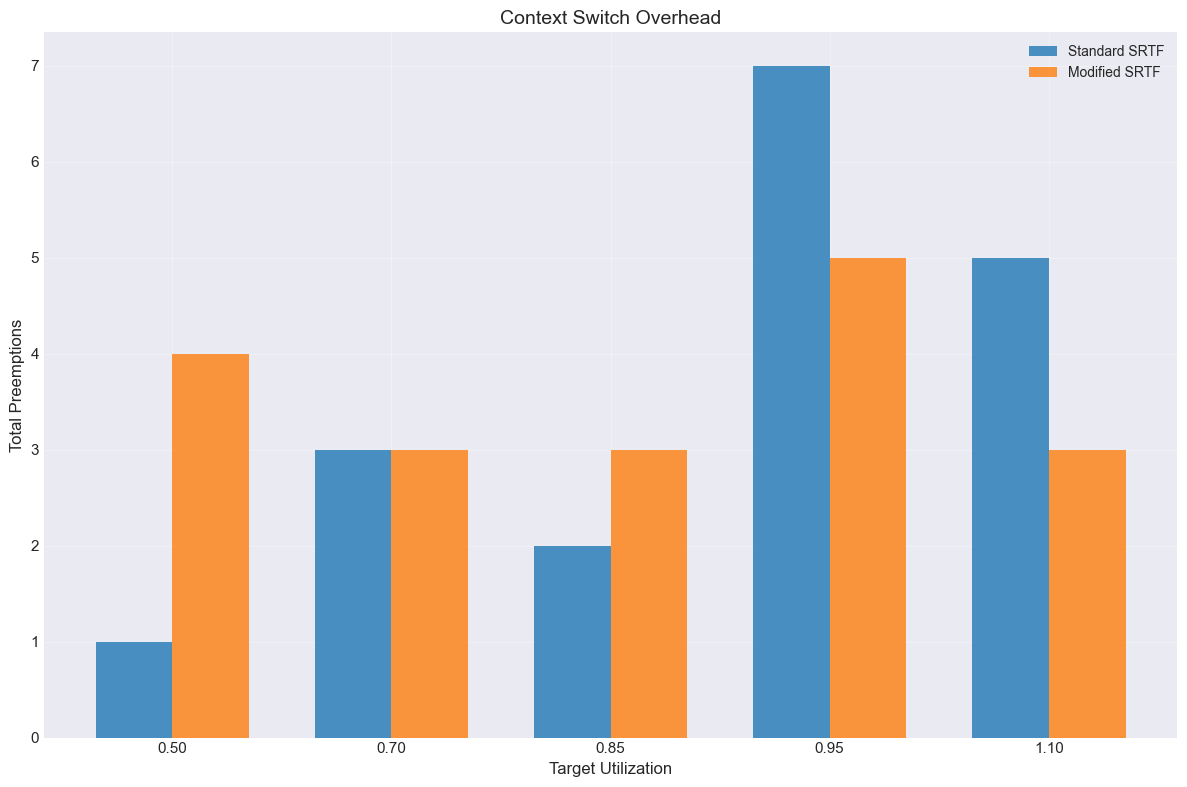

In [35]:
fig, ax7 = plt.subplots(figsize=(12, 8))

bars1 = ax7.bar(x - width/2, df_srtf['TotalPreemptions'], width, label='Standard SRTF', alpha=0.8)
bars2 = ax7.bar(x + width/2, df_modified['TotalPreemptions'], width, label='Modified SRTF', alpha=0.8)

ax7.set_xlabel('Target Utilization')
ax7.set_ylabel('Total Preemptions')
ax7.set_title('Context Switch Overhead')
ax7.set_xticks(x)
ax7.set_xticklabels([f'{u:.2f}' for u in utilization_levels])
ax7.legend()
ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

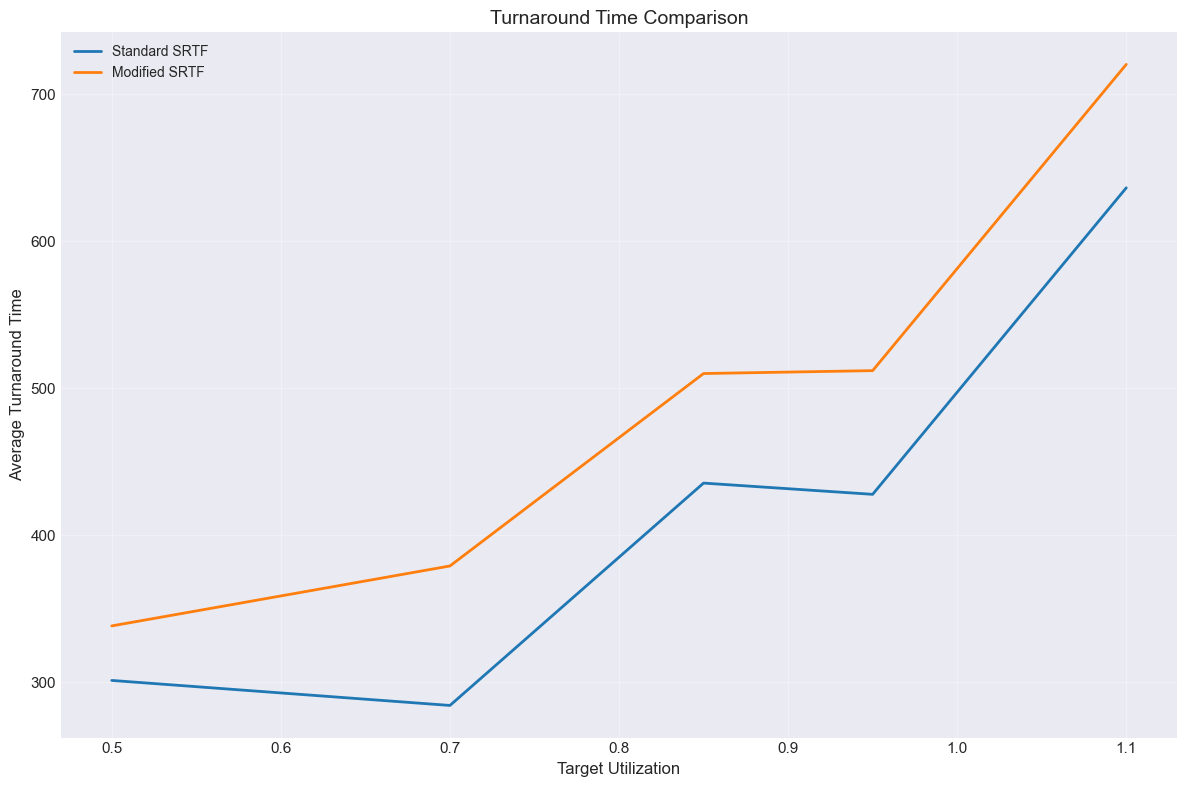

In [36]:
fig, ax8 = plt.subplots(figsize=(12, 8))

ax8.plot(utilization_levels, df_srtf['AvgTurnaroundTime'], label='Standard SRTF', linewidth=2, markersize=8)
ax8.plot(utilization_levels, df_modified['AvgTurnaroundTime'], label='Modified SRTF', linewidth=2, markersize=8)

ax8.set_xlabel('Target Utilization')
ax8.set_ylabel('Average Turnaround Time')
ax8.set_title('Turnaround Time Comparison')
ax8.legend()
ax8.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

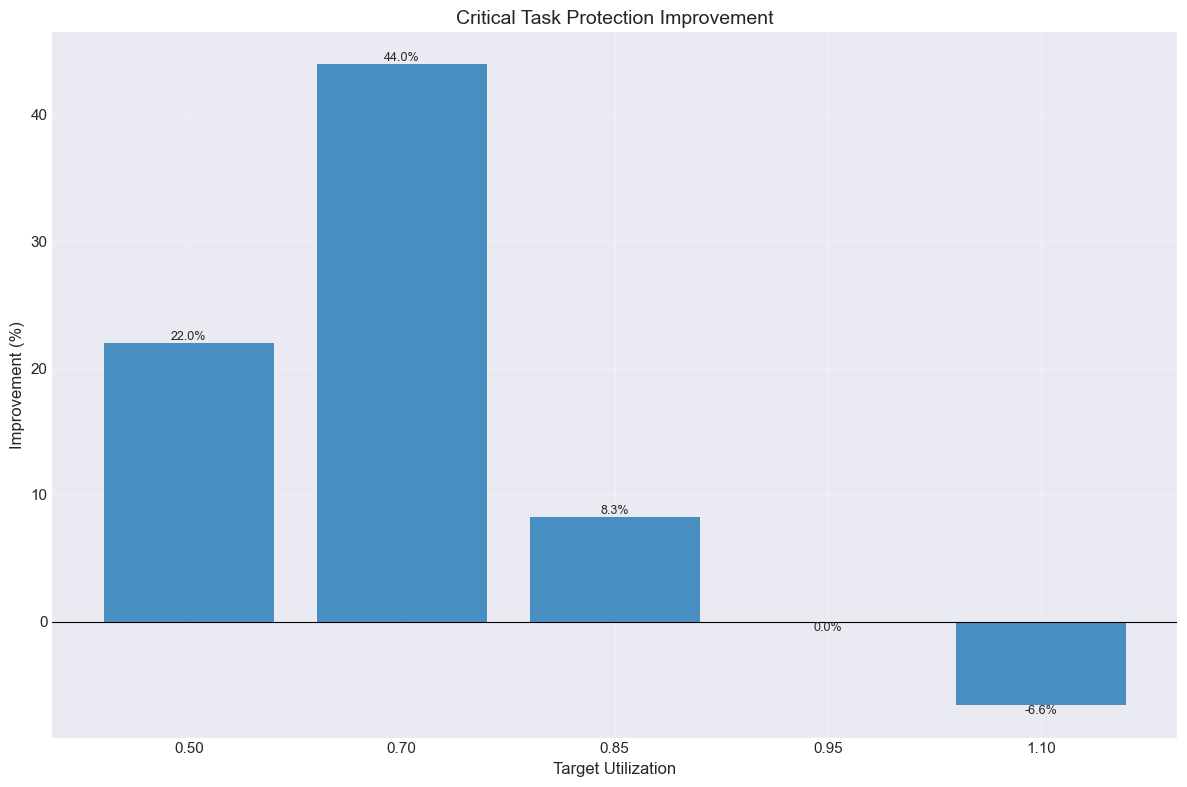

In [37]:
fig, ax9 = plt.subplots(figsize=(12, 8))

improvement = ((df_srtf['CriticalMisses'] - df_modified['CriticalMisses']) / (df_srtf['CriticalMisses'] + 0.1)) * 100

bars = ax9.bar(x, improvement, alpha=0.8)

ax9.set_xlabel('Target Utilization')
ax9.set_ylabel('Improvement (%)')
ax9.set_title('Critical Task Protection Improvement')
ax9.set_xticks(x)
ax9.set_xticklabels([f'{u:.2f}' for u in utilization_levels])
ax9.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax9.grid(True, alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, improvement)):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height, f'{val:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)
    
plt.tight_layout()
plt.show()